# 🦷 Diş Röntgeni Model Demo Notebook'u

Bu notebook, eğitilmiş `models/best.pt` YOLOv8 modelini **terminal komutu yazmadan** hızlıca test etmek için hazırlanmıştır.

Akış çok basittir:

1. `test_pics/` klasöründeki desteklenen görseller listelenir.
2. Notebook bu klasörden rastgele bir röntgen görseli seçer.
3. Seçilen görsel eğitilmiş modele gönderilir.
4. Tahmin edilen sınıf, güven skoru ve kutu bilgileri tablo olarak gösterilir.
5. Orijinal görsel ve modelin işaretlediği çıktı yan yana görüntülenir.

> Kullanıcı belirli bir görseli test etmek isterse aşağıdaki **Ayarlar** hücresinde `SELECTED_IMAGE_NAME` değerini örneğin `"0001.jpg"` olarak değiştirebilir.

> ⚠️ Bu proje portföy ve araştırma amaçlıdır. Model çıktıları klinik tanı veya tedavi önerisi olarak kullanılmamalıdır.

## 1. Kütüphaneler ve Proje Yolları

Bu hücre proje kök dizinini otomatik bulur ve `src/` klasöründeki yardımcı çıkarım fonksiyonlarını içe aktarır.

In [1]:
from __future__ import annotations

import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start_path: Path) -> Path:
    """Notebook hangi klasörden çalıştırılırsa çalıştırılsın proje kökünü bulur."""
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "models" / "best.pt").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError(
        "Proje kök dizini bulunamadı. Notebook'u proje klasörü içinde çalıştırdığınızdan emin olun."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dental_ai.inference import (  # noqa: E402
    SUPPORTED_IMAGE_EXTENSIONS,
    load_model,
    read_image_rgb,
    render_annotated_image_rgb,
    summarize_detections,
    validate_confidence_threshold,
    validate_image_path,
)

MODEL_PATH = PROJECT_ROOT / "models" / "best.pt"
TEST_PICS_DIR = PROJECT_ROOT / "test_pics"

print("Proje kökü bulundu ve gerekli dosyalar hazır.")
print(f"Model dosyası: {MODEL_PATH.relative_to(PROJECT_ROOT)}")
print(f"Test görselleri klasörü: {TEST_PICS_DIR.relative_to(PROJECT_ROOT)}")

Proje kökü bulundu ve gerekli dosyalar hazır.
Model dosyası: models/best.pt
Test görselleri klasörü: test_pics


## 2. Ayarlar

Varsayılan kullanımda notebook `test_pics/` klasöründen rastgele bir görsel seçer.

Belirli bir görseli test etmek için:

```python
SELECTED_IMAGE_NAME = "0001.jpg"
```

şeklinde değiştirebilirsiniz. Tekrar rastgele seçim yapmak için değeri `None` bırakın.

In [2]:
# Güven eşiği: Modelin gösterilecek tespitler için minimum güven skoru.
CONFIDENCE_THRESHOLD = 0.50

# Belirli bir görsel seçmek için dosya adını yazın. Rastgele seçim için None bırakın.
# Örnek: SELECTED_IMAGE_NAME = "0001.jpg"
SELECTED_IMAGE_NAME = None

# Tekrarlanabilir rastgele seçim için bir sayı verilebilir. Tam rastgele seçim için None bırakın.
# Örnek: RANDOM_SEED = 42
RANDOM_SEED = None

## 3. Test Görselini Seç

Bu hücre `test_pics/` klasöründeki desteklenen görselleri bulur ve ayarlara göre test edilecek görseli belirler.

In [3]:
TEST_IMAGES = sorted(
    path
    for path in TEST_PICS_DIR.glob("*")
    if path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS and "_result" not in path.stem
)

if not TEST_IMAGES:
    raise FileNotFoundError("test_pics klasöründe desteklenen formatta görsel bulunamadı.")

if SELECTED_IMAGE_NAME:
    selected_image_path = validate_image_path(TEST_PICS_DIR / SELECTED_IMAGE_NAME)
else:
    if RANDOM_SEED is not None:
        random.seed(RANDOM_SEED)
    selected_image_path = random.choice(TEST_IMAGES)

available_images_df = pd.DataFrame(
    {
        "No": range(1, len(TEST_IMAGES) + 1),
        "Dosya": [path.name for path in TEST_IMAGES],
        "Göreli Yol": [str(path.relative_to(PROJECT_ROOT)) for path in TEST_IMAGES],
    }
)

display(Markdown(f"### Seçilen test görseli: `{selected_image_path.name}`"))
display(Markdown(f"Toplam kullanılabilir test görseli: **{len(TEST_IMAGES)}**"))
display(available_images_df.head(20))

### Seçilen test görseli: `0015.jpg`

Toplam kullanılabilir test görseli: **20**

,No,Dosya,Göreli Yol
0,1,0001.jpg,test_pics/0001.jpg
1,2,0002.jpg,test_pics/0002.jpg
2,3,0003.jpg,test_pics/0003.jpg
3,4,0004.jpg,test_pics/0004.jpg
4,5,0005.jpg,test_pics/0005.jpg
5,6,0006.jpg,test_pics/0006.jpg
6,7,0007.jpg,test_pics/0007.jpg
7,8,0008.jpg,test_pics/0008.jpg
8,9,0009.jpg,test_pics/0009.jpg
9,10,0010.jpg,test_pics/0010.jpg


## 4. Modeli Yükle ve Tahmin Al

Bu hücre eğitilmiş modeli yükler, seçilen röntgen görselini modele gönderir ve tespitleri tabloya dönüştürür.

In [4]:
confidence_threshold = validate_confidence_threshold(CONFIDENCE_THRESHOLD)
model = load_model(MODEL_PATH)

results = model(str(selected_image_path), conf=confidence_threshold, verbose=False)
result = results[0]
detections = summarize_detections(model, result)

display(Markdown(f"### Analiz edilen görsel: `{selected_image_path.name}`"))
display(Markdown(f"**Güven eşiği:** `{confidence_threshold:.2f}`"))

if detections:
    detections_df = pd.DataFrame([item.as_dict() for item in detections])
    display(detections_df)

    best_detection = detections[0]
    display(
        Markdown(
            f"**En güçlü tahmin:** {best_detection.class_name_tr} "
            f"(`{best_detection.class_name}`) — güven: **%{best_detection.confidence_percent:.2f}**"
        )
    )
else:
    display(Markdown("**Sonuç:** Belirlenen güven eşiğinin üzerinde bulgu tespit edilmedi."))

### Analiz edilen görsel: `0015.jpg`

**Güven eşiği:** `0.50`

,Sınıf,Model Etiketi,Güven,Güven (%),"Kutu (x1, y1, x2, y2)",Öneri
0,Dolgu,Fillings,0.8822,88.22,"(128, 134, 172, 179)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
1,Dolgu,Fillings,0.8761,87.61,"(332, 88, 359, 135)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
2,Dolgu,Fillings,0.8684,86.84,"(346, 132, 384, 177)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
3,Dolgu,Fillings,0.8540,85.40,"(177, 95, 201, 146)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
4,Dolgu,Fillings,0.8012,80.12,"(153, 88, 179, 136)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
5,Dolgu,Fillings,0.7466,74.66,"(320, 143, 367, 190)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
6,İmplant,Implant,0.7202,72.02,"(280, 105, 299, 155)",Kemik seviyesi ve peri-implant doku sağlığı ru...
7,Dolgu,Fillings,0.7105,71.05,"(306, 153, 338, 199)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
8,Dolgu,Fillings,0.5731,57.31,"(198, 98, 215, 149)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...
9,Dolgu,Fillings,0.5523,55.23,"(178, 153, 209, 201)",Mevcut dolgunun kenar uyumu ve sekonder çürük ...


**En güçlü tahmin:** Dolgu (`Fillings`) — güven: **%88.22**

## 5. Orijinal Görsel ve Model Çıktısı

Sol tarafta modele verilen orijinal röntgen, sağ tarafta ise modelin kutu ve etiket çizdiği çıktı gösterilir.

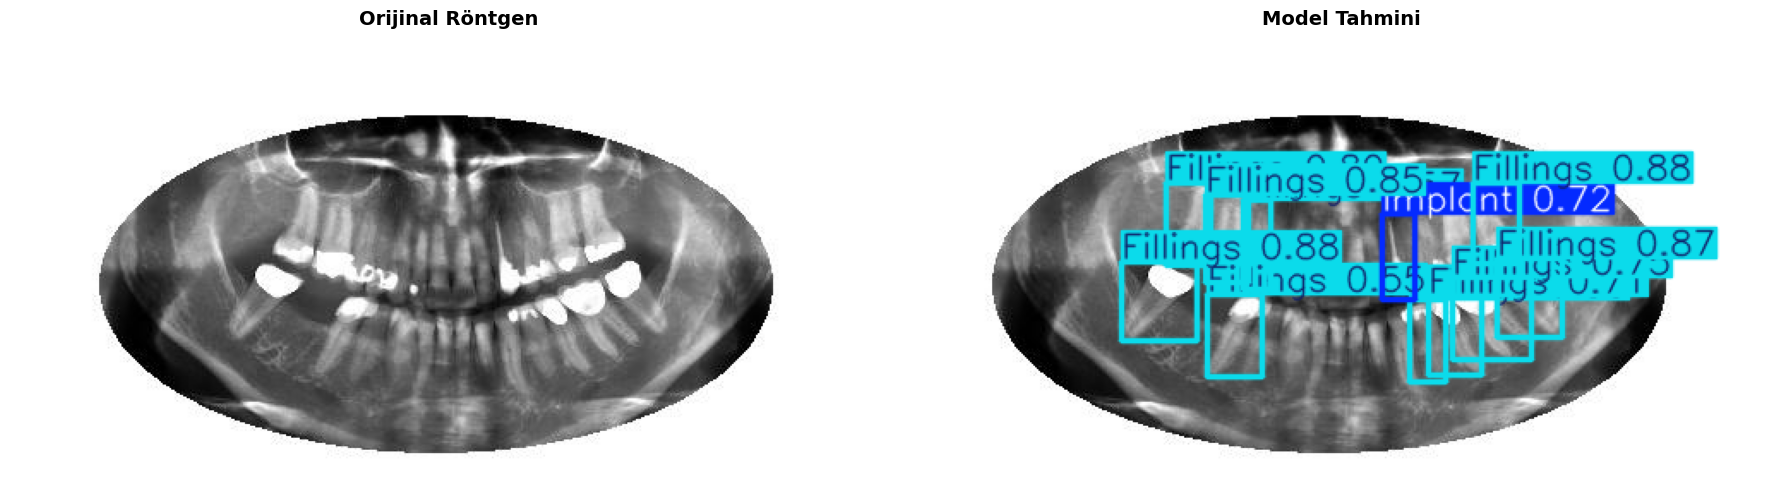

> ⚠️ Bu çıktı yalnızca yapay zeka modelinin tahminidir; klinik tanı veya tedavi önerisi olarak kullanılmamalıdır.

In [5]:
original_rgb = read_image_rgb(selected_image_path)
annotated_rgb = render_annotated_image_rgb(result)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].imshow(original_rgb)
axes[0].set_title("Orijinal Röntgen", fontsize=14, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(annotated_rgb)
axes[1].set_title("Model Tahmini", fontsize=14, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

display(
    Markdown(
        "> ⚠️ Bu çıktı yalnızca yapay zeka modelinin tahminidir; "
        "klinik tanı veya tedavi önerisi olarak kullanılmamalıdır."
    )
)

## 6. Belirli Bir Görseli Test Etmek

Farklı bir görsel test etmek için **Ayarlar** hücresindeki şu satırı değiştirin:

```python
SELECTED_IMAGE_NAME = "0001.jpg"
```

Örneğin:

```python
SELECTED_IMAGE_NAME = "0012.webp"
CONFIDENCE_THRESHOLD = 0.25
```

Daha sonra notebook'u baştan sona tekrar çalıştırmanız yeterlidir.